# 18b · GSE232381 · bulk_RNA_seq · Dynamic Tree Cut on the Ward trees

Reads `hub_matrix.csv`, `hub_genes.csv` and `hub_matrix_annotations.csv` (notebook 17).

**Method.** Dynamic Tree Cut (Langfelder P, Zhang B, Horvath S. Defining clusters from a hierarchical
cluster tree: the Dynamic Tree Cut package for R. *Bioinformatics* 2008;24:719-720,
doi:10.1093/bioinformatics/btm563) finds groups from the shape of a hierarchical tree, branch by
branch, instead of cutting the whole tree at one height or at a fixed number of groups. No k is given.

**Trees.** The same as notebook 17: `ward.D2` on Minkowski distance with p = 2, over the 25 samples x
GSE65391 hub genes (z-scored per gene), one tree for samples and one for genes.

**Settings.** `method = "hybrid"` (uses the distance matrix as well as the tree), `deepSplit = 2`, PAM
stage on (package default: leftover objects are assigned to the nearest cluster). `deepSplit = 2` is
the value used in endotypes-proteomics (notebook 10).

**The one choice: `minClusterSize`.** It sets the smallest group the method may report. The package
default is 20. endotypes-proteomics chose 5 after a scan (notebook 02). Here the choice is shown as a
scan over 20, 15, 10, 5, 3 and 2 (the smallest possible group), on both axes. For genes, agreement with
the GSE65391 modules (adjusted Rand index, ARI; Hubert and Arabie 1985) is reported as a check. Each
module contributes up to 10 hub genes, so a module can appear as its own group only at sizes of 10 or below.

**Figures** at `minClusterSize = 5`, the endotypes-proteomics value.

## Read the matrix, build the Ward trees, define two functions

In [1]:
source("../src/paths.R")
suppressMessages({library(dynamicTreeCut); library(ComplexHeatmap); library(circlize)})
X    <- as.matrix(read.csv(art("GSE232381", "hub_matrix.csv"), row.names = 1, check.names = FALSE))
gene_module <- read.csv(art("GSE232381", "hub_genes.csv"))$module
ann  <- read.csv(art("GSE232381", "hub_matrix_annotations.csv"))
Xc <- pmin(pmax(X, -2.5), 2.5)
d_patients <- dist(X, method = "minkowski", p = 2);    hc_patients <- hclust(d_patients, method = "ward.D2")
d_genes    <- dist(t(X), method = "minkowski", p = 2); hc_genes    <- hclust(d_genes, method = "ward.D2")
ari <- function(a, b) {
  tab <- table(a, b); c2 <- function(x) x * (x - 1) / 2
  e <- sum(c2(rowSums(tab))) * sum(c2(colSums(tab))) / c2(sum(tab))
  (sum(c2(tab)) - e) / ((sum(c2(rowSums(tab))) + sum(c2(colSums(tab)))) / 2 - e)
}
dtc <- function(hc, d, size) cutreeDynamic(hc, distM = as.matrix(d), method = "hybrid", deepSplit = 2,
                                           minClusterSize = size, verbose = 0)

**Explanation**
- `library(ComplexHeatmap)` draws heatmaps with dendrograms and annotation strips (Gu Z, Eils R, Schlesner M.
  Complex heatmaps reveal patterns and correlations in multidimensional genomic data. *Bioinformatics*
  2016;32:2847-2849). `library(circlize)` provides `colorRamp2()`, which maps numbers to colours (Gu Z, Gu L,
  Eils R, Schlesner M, Brors B. circlize implements and enhances circular visualization in R. *Bioinformatics*
  2014;30:2811-2812).
- `X` is the matrix written by the Ward heatmap notebook of this study; `as.matrix(read.csv(..., row.names = 1))`
  reads it with the samples as row names.
- The trees, `ari()` and `dtc()` as in notebook 08b.

**Scan.** For each minimum size: the number of groups (label 0 = not assigned), group sizes, and for
genes the ARI against the WGCNA modules.

## Scan the minimum group size

In [2]:
SIZES <- c(20, 15, 10, 5, 3, 2)
scan <- do.call(rbind, lapply(SIZES, function(s) {
  gp <- dtc(hc_patients, d_patients, s); gg <- dtc(hc_genes, d_genes, s)
  data.frame(minClusterSize = s,
             sample_groups = length(setdiff(unique(gp), 0)), samples_unassigned = sum(gp == 0),
             sample_group_sizes = paste(sort(table(gp[gp != 0]), decreasing = TRUE), collapse = " "),
             gene_groups = length(setdiff(unique(gg), 0)), genes_unassigned = sum(gg == 0),
             gene_ARI_vs_modules = round(ari(gg, gene_module), 3))
}))
scan

minClusterSize,sample_groups,samples_unassigned,sample_group_sizes,gene_groups,genes_unassigned,gene_ARI_vs_modules
<dbl>,<int>,<int>,<chr>,<int>,<int>,<dbl>
20,1,1,24,3,0,0.131
15,1,1,24,4,0,0.160
10,1,1,24,7,0,0.409
5,3,1,12 7 5,11,0,0.539
3,4,1,9 7 5 3,14,0,0.605
2,4,1,9 7 5 3,14,0,0.605


**Explanation**
- As in notebook 08b.

**Result.**
- **Genes.** Agreement with the GSE65391 modules is highest at `minClusterSize` 3 and 2 (14 groups,
  ARI = 0.605); at 5, 11 groups and ARI = 0.539. In GSE65391 the ARI is 1.000.
- **Samples.** At 20, 15 and 10 one group of 24; at 5 three groups (12, 7 and 5); at 3 and 2 four groups (9,
  7, 5 and 3). One sample is unassigned at every size.

## Cut both trees at minimum size 5

In [3]:
SIZE <- 5
patient_group <- factor(dtc(hc_patients, d_patients, SIZE))
gene_group    <- factor(dtc(hc_genes, d_genes, SIZE))
table(patient_group); table(module = gene_module, dtc_group = gene_group)

patient_group
 0  1  2  3 
 1 12  7  5 

             dtc_group
module         1  2  3  4  5  6  7  8  9 10 11
  black        0  0  0  0  0  0 10  0  0  0  0
  blue         2  0  0  8  0  0  0  0  0  0  0
  brown        0  0 10  0  0  0  0  0  0  0  0
  cyan         0  0  0  0  0  0  0  9  0  0  0
  green        1  1  0  0  0  0  0  0  0  5  3
  greenyellow  9  0  0  1  0  0  0  0  0  0  0
  magenta      0  0  0  2  0  6  0  0  0  0  0
  pink         0  0  0  0  0  0  0  0  9  0  0
  purple       9  1  0  0  0  0  0  0  0  0  0
  red          0  9  0  0  0  0  0  0  0  0  1
  salmon       0  0  4  0  5  0  0  0  0  0  1
  tan          0  0  0  1  0  5  0  0  0  0  0
  turquoise    0  4  0  0  6  0  0  0  0  0  0
  yellow       0  3  0  0  1  0  0  0  0  1  0

**Explanation**
- As in notebook 08b.

**Result.** At `minClusterSize = 5`, three modules keep all their measured hub genes in one group of their
own: black (interferon, 10), cyan (neutrophil granule, 9) and pink (plasma cell, 9). Brown's 10 genes share a
group with 4 salmon genes; red keeps 9 of 10 in one group.

## Draw the heatmap with the groups as strips

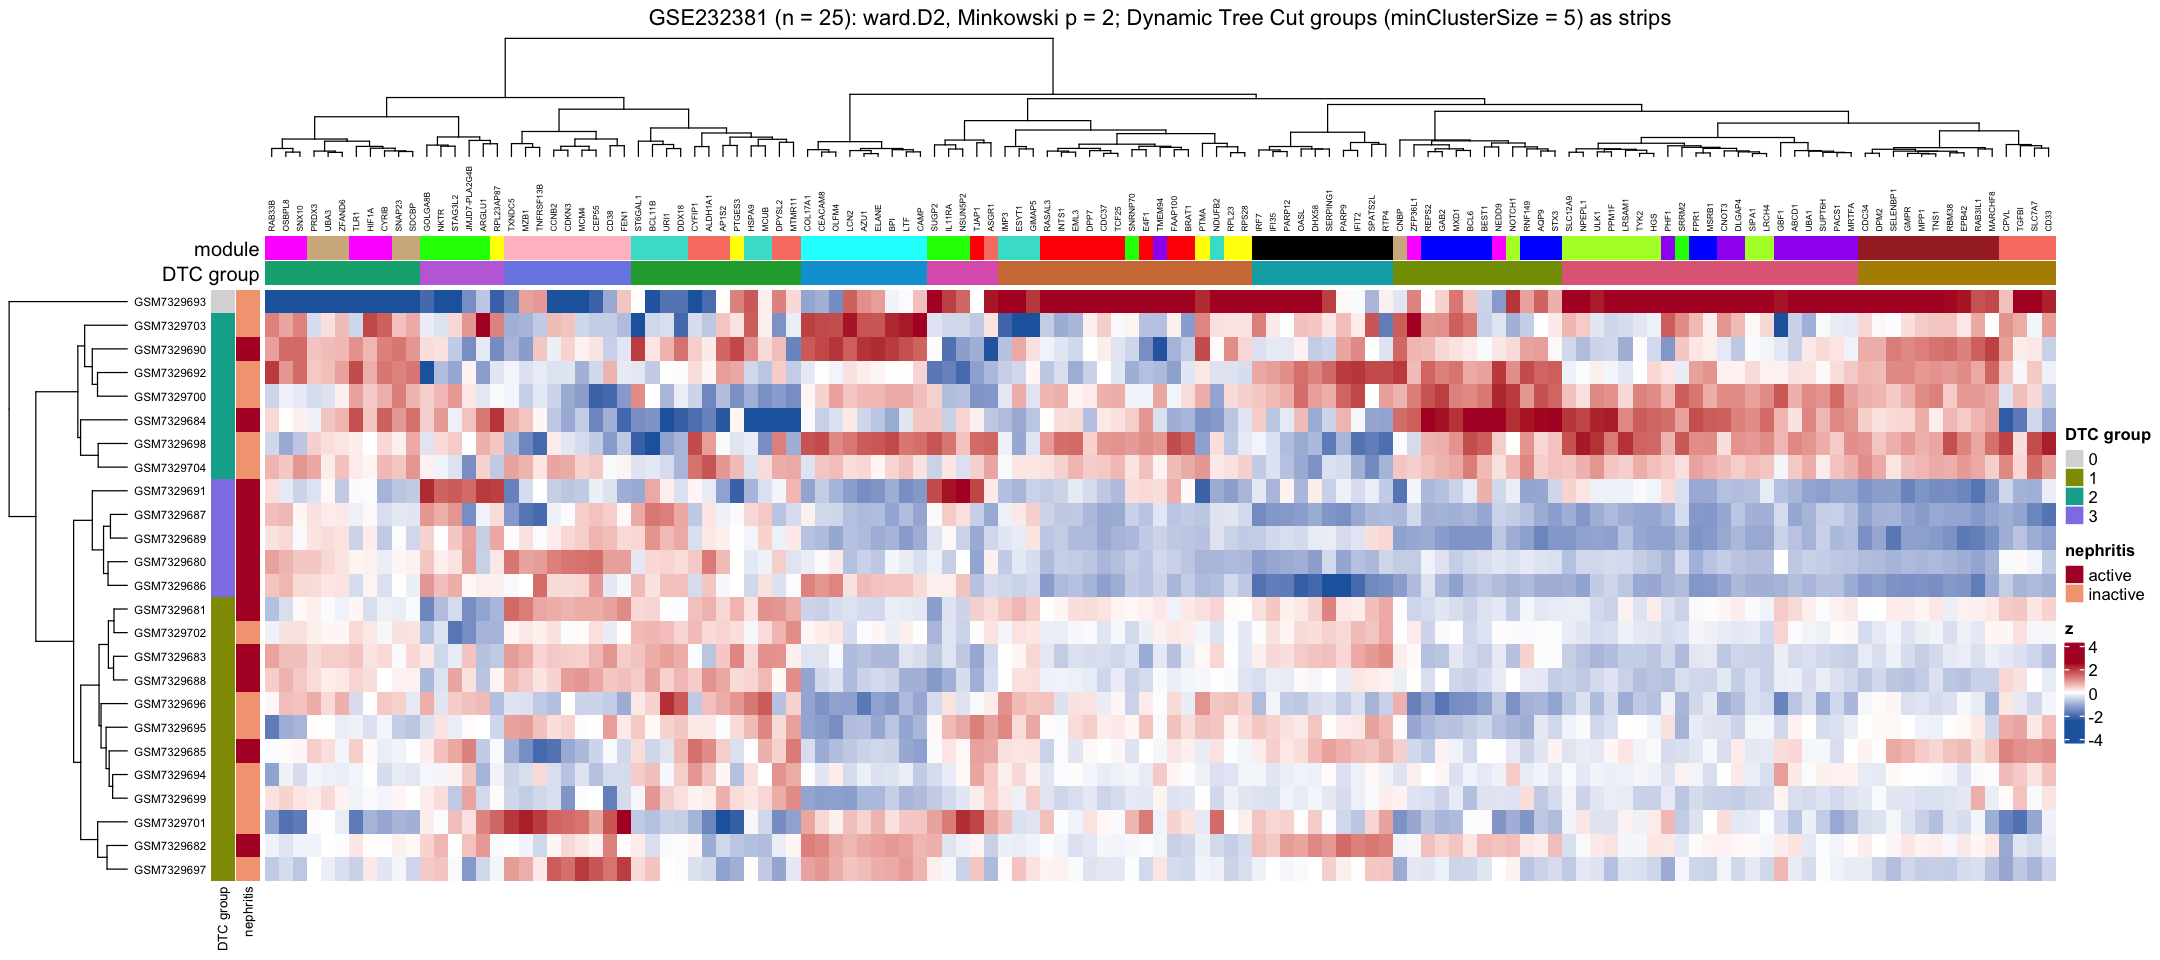

In [4]:
# grey only for label 0 (not assigned); every assigned group gets its own colour
grp_col <- function(f) { lv <- levels(f); cols <- setNames(hcl.colors(length(lv), "Dark 3"), lv); if ("0" %in% lv) cols["0"] <- "grey85"; cols }
left <- rowAnnotation("DTC group" = patient_group, nephritis = ann$nephritis,
                      col = list("DTC group" = grp_col(patient_group), nephritis = c(active = "#B2182B", inactive = "#F4A582")),
                      annotation_name_gp = gpar(fontsize = 8))
top <- HeatmapAnnotation(module = gene_module, "DTC group" = gene_group,
                         col = list(module = setNames(unique(gene_module), unique(gene_module)), "DTC group" = grp_col(gene_group)),
                         show_legend = c(module = FALSE, "DTC group" = FALSE), annotation_name_side = "left")
options(repr.plot.width = 18, repr.plot.height = 8)
figure <- function() {
  Heatmap(Xc, name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
          cluster_rows = hc_patients, cluster_columns = hc_genes,
          row_dend_side = "left", column_dend_side = "top",
          row_dend_width = unit(25, "mm"), column_dend_height = unit(25, "mm"),
          show_row_names = TRUE, row_names_side = "left", row_names_gp = gpar(fontsize = 7), column_names_side = "top", column_names_gp = gpar(fontsize = 5),
          top_annotation = top, left_annotation = left,
          column_title = sprintf("GSE232381 (n = 25): ward.D2, Minkowski p = 2; Dynamic Tree Cut groups (minClusterSize = %d) as strips", SIZE))
}
for (device in c("inline", "png")) {               # shown here, and saved as a 300 dpi PNG
  if (device == "png") png(fig("GSE232381", "18b_GSE232381_bulk_RNA_seq_dynamic_tree_cut_1.png"), width = 18, height = 8, units = "in", res = 300)
  out <- figure(); if (inherits(out, c("Heatmap", "HeatmapList"))) draw(out)
  if (device == "png") invisible(dev.off())
}

**Explanation**
- As in notebook 08b.